## Humdrum Parser Summary

The `HumdrumParser` class successfully parses Humdrum fretboard files and extracts:

### Key Features:
1. **Metadata Extraction**: Title, composer, year, tempo
2. **Tuning Information**: 
   - Absolute tuning (lowest string pitch, e.g., E2)
   - Relative tuning (semitone offsets for each string)
3. **Event Parsing**:
   - Rhythm tokens (`**recip`) converted to durations in quarter notes
   - Fret tokens (`**fret`) parsed into fret indices and sounding status
   - Cumulative onset times calculated
4. **Active Coordinates**: For each event, automatically computes which (fret, string) pairs are sounding

### Data Structures:
- **FretboardEvent**: Individual note/chord with timing and fret information
- **FretboardScore**: Complete transcription with metadata and events
- **HumdrumParser**: Main parser class with customizable methods

### Example Usage:
```python
parser = HumdrumParser()
score = parser.parse_file("path/to/file.frt.txt")
print(f"Parsed {len(score.events)} events from {score.title}")
```

The parser handles:
- Dotted rhythms (e.g., `4.` = 1.5 quarter notes)
- Multiple simultaneous notes/chords
- Both sounding (`|fret`) and silent (`-`) strings
- Proper time accumulation across events

In [ ]:
import re
from fractions import Fraction
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass
import numpy as np

@dataclass
class FretboardEvent:
    """Represents a single fretboard event with timing and string-fret information."""
    onset_time: float  # Cumulative time in quarter notes
    duration: float    # Duration in quarter notes
    num_strings: int   # Number of strings
    frets: List[int]   # Fret indices per string (0 = open, -1 = silent)
    sounding: List[bool]  # Whether each string is sounding (True) or silent (False)
    
    @property
    def active_coordinates(self) -> List[Tuple[int, int]]:
        """Returns list of (fret, string) tuples for sounding strings.
        String indices are 1-indexed (1 to num_strings)."""
        coords = []
        for string_idx, (fret, is_sounding) in enumerate(zip(self.frets, self.sounding)):
            if is_sounding:
                coords.append((fret, string_idx + 1))  # 1-indexed strings
        return coords
    
    def __repr__(self):
        return (f"FretboardEvent(t={self.onset_time}, d={self.duration}, "
                f"frets={self.frets}, sounding={self.sounding})")


@dataclass
class FretboardScore:
    """Container for a complete fretboard transcription."""
    title: Optional[str]
    composer: Optional[str]
    year: Optional[str]
    absolute_tuning: Tuple[str, int]  # (note, octave), e.g., ('E', 2)
    relative_tuning: List[int]  # Semitones above lowest string
    tempo: Optional[int]  # BPM
    events: List[FretboardEvent]
    
    @property
    def num_strings(self) -> int:
        return len(self.relative_tuning)


class HumdrumParser:
    """Parser for Humdrum fretboard notation files."""
    
    PITCH_CLASS_TO_MIDI = {
        'C': 0, 'D': 2, 'E': 4, 'F': 5, 'G': 7, 'A': 9, 'B': 11
    }
    
    def __init__(self):
        self.absolute_tuning = None
        self.relative_tuning = None
        self.num_strings = None
        self.title = None
        self.composer = None
        self.year = None
        self.tempo = None
    
    def parse_file(self, filepath: str) -> FretboardScore:
        """Parse a Humdrum fretboard file and return FretboardScore."""
        with open(filepath, 'r') as f:
            lines = f.readlines()
        
        return self.parse_lines(lines)
    
    def parse_lines(self, lines: List[str]) -> FretboardScore:
        """Parse lines from a Humdrum file."""
        # Extract reference records (metadata)
        self._parse_reference_records(lines)
        
        # Find spine lines and data rows
        recip_col, fret_col = self._find_spine_columns(lines)
        
        # Parse events
        events = self._parse_events(lines, recip_col, fret_col)
        
        score = FretboardScore(
            title=self.title,
            composer=self.composer,
            year=self.year,
            absolute_tuning=self.absolute_tuning,
            relative_tuning=self.relative_tuning,
            tempo=self.tempo,
            events=events
        )
        
        return score
    
    def _parse_reference_records(self, lines: List[str]) -> None:
        """Extract metadata from reference records (lines starting with '!!!')."""
        for line in lines:
            line = line.rstrip('\n')
            if line.startswith('!!!OTL:'):
                self.title = line[7:].strip()
            elif line.startswith('!!!COM:'):
                self.composer = line[7:].strip()
            elif line.startswith('!!!YEAR:'):
                self.year = line[8:].strip()
    
    def _find_spine_columns(self, lines: List[str]) -> Tuple[int, int]:
        """Find column indices for **recip and **fret spines."""
        for line in lines:
            line = line.rstrip('\n')
            if line.startswith('**'):
                parts = line.split('\t')
                recip_col = None
                fret_col = None
                for i, part in enumerate(parts):
                    if part == '**recip':
                        recip_col = i
                    elif part == '**fret':
                        fret_col = i
                if recip_col is not None and fret_col is not None:
                    return recip_col, fret_col
        
        raise ValueError("Could not find **recip and **fret spines")
    
    def _parse_events(self, lines: List[str], recip_col: int, fret_col: int) -> List[FretboardEvent]:
        """Parse fretboard events from data rows."""
        # First pass: extract metadata from interpretation lines
        self._parse_metadata_lines(lines, fret_col)
        
        events = []
        onset_time = 0.0  # In quarter notes
        
        for line in lines:
            line = line.rstrip('\n')
            
            # Skip empty lines and comments
            if not line or line.startswith('!!!'):
                continue
            
            # Skip spine markers
            if line.startswith('**'):
                continue
            
            # Handle interpretation lines
            if line.startswith('*'):
                # Check for tempo marker
                if line.startswith('*MM'):
                    match = re.search(r'\*MM(\d+)', line)
                    if match:
                        self.tempo = int(match.group(1))
                continue
            
            # Handle data rows
            if line.startswith('='):
                continue
            
            # Parse data row
            parts = line.split('\t')
            if len(parts) > max(recip_col, fret_col):
                recip_token = parts[recip_col]
                fret_token = parts[fret_col]
                
                # Parse duration
                duration = self._parse_recip_token(recip_token)
                
                # Parse fret information
                frets, sounding = self._parse_fret_token(fret_token)
                
                # Create event
                event = FretboardEvent(
                    onset_time=onset_time,
                    duration=duration,
                    num_strings=self.num_strings,
                    frets=frets,
                    sounding=sounding
                )
                events.append(event)
                
                onset_time += duration
        
        return events
    
    def _parse_metadata_lines(self, lines: List[str], fret_col: int) -> None:
        """Extract tuning information from interpretation lines."""
        for line in lines:
            line = line.rstrip('\n')
            
            if not line.startswith('*'):
                continue
            
            parts = line.split('\t')
            if len(parts) <= fret_col:
                continue
            
            fret_part = parts[fret_col]
            
            # Parse absolute tuning (AT)
            if fret_part.startswith('*AT:'):
                tuning_str = fret_part[4:]
                self.absolute_tuning = self._parse_absolute_tuning(tuning_str)
            
            # Parse relative tuning (RT)
            if fret_part.startswith('*RT:'):
                tuning_str = fret_part[4:]
                self.relative_tuning = self._parse_relative_tuning(tuning_str)
                self.num_strings = len(self.relative_tuning)
    
    def _parse_absolute_tuning(self, tuning_str: str) -> Tuple[str, int]:
        """Parse absolute tuning string (e.g., 'E2') into (note, octave)."""
        match = re.match(r"([A-G])([b#]?)(\d+)", tuning_str)
        if match:
            note = match.group(1)
            # accidental = match.group(2)  # Could be used if needed
            octave = int(match.group(3))
            return (note, octave)
        raise ValueError(f"Invalid absolute tuning: {tuning_str}")
    
    def _parse_relative_tuning(self, tuning_str: str) -> List[int]:
        """Parse relative tuning string (e.g., '0:5:10:15:19:24') into list of semitones."""
        return [int(x) for x in tuning_str.split(':')]
    
    def _parse_recip_token(self, token: str) -> float:
        """Parse **recip token into duration in quarter notes.
        
        Examples:
            '4' -> 1.0 (quarter note)
            '8' -> 0.5 (eighth note)
            '4.' -> 1.5 (dotted quarter)
            '16' -> 0.25 (sixteenth note)
        """
        # Extract base duration
        match = re.match(r"(\d+)(\.?)", token)
        if match:
            denominator = int(match.group(1))
            dotted = match.group(2) == '.'
            
            # Convert from reciprocal notation to duration in quarter notes
            # In Humdrum, '4' means 1/4 (quarter note), '8' means 1/8 (eighth), etc.
            base_duration = 4.0 / denominator
            
            if dotted:
                base_duration *= 1.5  # Dotted note adds half its value
            
            return base_duration
        
        raise ValueError(f"Invalid recip token: {token}")
    
    def _parse_fret_token(self, token: str) -> Tuple[List[int], List[bool]]:
        """Parse **fret token into frets and sounding status per string.
        
        Example:
            '|6 - |7 - - -' for 6 strings where strings 1,3 are played
            returns frets=[6, 0, 7, 0, 0, 0], sounding=[True, False, True, False, False, False]
        """
        # Split by spaces to get individual string tokens
        string_tokens = token.split()
        
        frets = []
        sounding = []
        
        for s_token in string_tokens:
            if s_token == '-':
                # Silent string
                frets.append(-1)  # Use -1 to indicate silent
                sounding.append(False)
            elif s_token.startswith('|'):
                # Sounding string
                fret_str = s_token[1:]
                if fret_str == '':
                    # Bare pipe means open string (fret 0)
                    fret_num = 0
                else:
                    fret_num = int(fret_str)
                frets.append(fret_num)
                sounding.append(True)
            else:
                raise ValueError(f"Invalid string token: {s_token}")
        
        return frets, sounding


print("Parser initialized.")

Parser initialized and ready to test!


# Input file below

In [ ]:
parser = HumdrumParser()
score = #insert Score below
# score = parser.parse_file("/Users/mchiu/Documents/code/emoFretboards/anthonyVideoFretPos/Bach.PartitaForLute.txt")

print(f"Title: {score.title}")
print(f"Composer: {score.composer}")
print(f"Year: {score.year}")
print(f"Tempo: {score.tempo} BPM")
print(f"Absolute Tuning: {score.absolute_tuning}")
print(f"Relative Tuning: {score.relative_tuning}")
print(f"Number of Strings: {score.num_strings}")
print(f"Total Events: {len(score.events)}")
print("\nFirst 5 events:")
for i, event in enumerate(score.events[:5]):
    print(f"  Event {i}: {event}")
    print(f"    Active coordinates: {event.active_coordinates}")

Title: "Prelude" from Partita for Lute in C minor
Composer: Bach
Year: None
Tempo: 118 BPM
Absolute Tuning: ('E', 2)
Relative Tuning: [0, 5, 10, 15, 19, 24]
Number of Strings: 6
Total Events: 44

First 5 events:
  Event 0: FretboardEvent(t=0.0, d=0.5, frets=[-1, 0, -1, -1, -1, -1], sounding=[False, True, False, False, False, False])
    Active coordinates: [(0, 2)]
  Event 1: FretboardEvent(t=0.5, d=0.25, frets=[-1, -1, -1, 2, -1, -1], sounding=[False, False, False, True, False, False])
    Active coordinates: [(2, 4)]
  Event 2: FretboardEvent(t=0.75, d=0.25, frets=[-1, -1, -1, -1, 0, -1], sounding=[False, False, False, False, True, False])
    Active coordinates: [(0, 5)]
  Event 3: FretboardEvent(t=1.0, d=0.5, frets=[-1, -1, -1, -1, 1, -1], sounding=[False, False, False, False, True, False])
    Active coordinates: [(1, 5)]
  Event 4: FretboardEvent(t=1.5, d=0.5, frets=[-1, -1, -1, -1, -1, 0], sounding=[False, False, False, False, False, True])
    Active coordinates: [(0, 6)]


In [4]:
# Detailed verification of parser correctness
print("=" * 60)
print("PARSER VERIFICATION")
print("=" * 60)

# Check timing accumulation
print("\nTiming Verification (first 10 events):")
for i, event in enumerate(score.events[:10]):
    print(f"  Event {i:2d}: onset={event.onset_time:6.2f}, duration={event.duration:5.2f}, "
          f"coords={event.active_coordinates}")

# Verify total duration
total_duration = sum(event.duration for event in score.events)
print(f"\nTotal Duration: {total_duration} quarter notes ({total_duration / 4} whole notes)")

# Check specific events with multiple notes (chords)
print("\nChord Events (multiple sounding strings):")
for i, event in enumerate(score.events):
    if len(event.active_coordinates) > 1:
        print(f"  Event {i}: {event.active_coordinates} with duration {event.duration}")
        if i >= 3:  # Just show first few
            break

# Verify rhythm parsing
print("\nRhythm Token Examples:")
test_tokens = ["4", "8", "16", "4.", "8.", "2"]
parser_test = HumdrumParser()
for token in test_tokens:
    duration = parser_test._parse_recip_token(token)
    print(f"  {token:3s} -> {duration} quarter notes")

PARSER VERIFICATION

Timing Verification (first 10 events):
  Event  0: onset=  0.00, duration= 0.50, coords=[(0, 2)]
  Event  1: onset=  0.50, duration= 0.25, coords=[(2, 4)]
  Event  2: onset=  0.75, duration= 0.25, coords=[(0, 5)]
  Event  3: onset=  1.00, duration= 0.50, coords=[(1, 5)]
  Event  4: onset=  1.50, duration= 0.50, coords=[(0, 6)]
  Event  5: onset=  2.00, duration= 0.50, coords=[(4, 6)]
  Event  6: onset=  2.50, duration= 0.50, coords=[(5, 6)]
  Event  7: onset=  3.00, duration= 0.50, coords=[(0, 4)]
  Event  8: onset=  3.50, duration= 0.50, coords=[(5, 6)]
  Event  9: onset=  4.00, duration= 0.50, coords=[(1, 1)]

Total Duration: 16.75 quarter notes (4.1875 whole notes)

Chord Events (multiple sounding strings):
  Event 35: [(0, 1), (1, 4)] with duration 0.25

Rhythm Token Examples:
  4   -> 1.0 quarter notes
  8   -> 0.5 quarter notes
  16  -> 0.25 quarter notes
  4.  -> 1.5 quarter notes
  8.  -> 0.75 quarter notes
  2   -> 2.0 quarter notes


## Outline

1. **Centroid Calculation** - Map events to 2D fretboard positions (the $\Phi$ mapping)
   - Extract active coordinates from each event
   - Calculate mean (fret, string) position
   
2. **Pitch Calculation** - Convert fretboard positions to MIDI pitches
   - Apply absolute and relative tuning
   - Calculate realized pitches for all sounding strings
   
3. **Distance Metrics** - Implement three distance calculations
   - Euclidean distance
   - Manhattan distance  
   - Cosine distance
   - Handle open string special case (fixed cost D=1)
   
4. **Fitts' Law Application** - Calculate gestural effort
   - Index of Difficulty (ID)
   - Index of Performance (IP)
   - Overall effort ($\eta$)

In [43]:
import math
from enum import Enum

class DistanceMetric(Enum):
    """Enumeration of distance metrics for fretboard movement."""
    EUCLIDEAN = "euclidean"
    MANHATTAN = "manhattan"
    COSINE = "cosine"


class FretboardAnalyzer:
    """Analyzes fretboard events for pitch, position, and gestural effort."""
    
    def __init__(self, score: FretboardScore):
        """Initialize analyzer with a FretboardScore."""
        self.score = score
        self.absolute_tuning = score.absolute_tuning
        self.relative_tuning = score.relative_tuning
        self.num_strings = score.num_strings
    
    # ========== CENTROID CALCULATION ==========
    
    def calculate_centroid(self, event: FretboardEvent) -> Tuple[float, float]:
        """
        Calculate the centroid (mean position) of sounding strings for an event.
        
        Maps fretboard event to 2D Cartesian position Φ(E_n) = (κ̄_n, j̄_n)
        
        For single-note events: returns the (fret, string) coordinate
        For chord events: returns the mean (fret, string) position
        
        Args:
            event: FretboardEvent to analyze
            
        Returns:
            Tuple of (mean_fret, mean_string) position
            Returns (0, 0) if no strings are sounding
        """
        coords = event.active_coordinates
        
        if not coords:
            return (0.0, 0.0)
        
        if len(coords) == 1:
            # Single note: return fret and string as floats
            fret, string = coords[0]
            return (float(fret), float(string))
        
        # Chord: calculate centroid
        mean_fret = sum(fret for fret, _ in coords) / len(coords)
        mean_string = sum(string for _, string in coords) / len(coords)
        
        return (mean_fret, mean_string)
    
    def centroids_for_score(self) -> List[Tuple[float, float]]:
        """Calculate centroids for all events in the score."""
        return [self.calculate_centroid(event) for event in self.score.events]
    
    # ========== PITCH CALCULATION ==========
    
    def calculate_absolute_pitch_midi(self) -> int:
        """
        Calculate the absolute lowest pitch (p_0) as MIDI number.
        
        Uses formula: p_0 = 12*(o + 1) + pc(n)
        where n is pitch class and o is octave
        
        Returns:
            MIDI number of lowest string's open pitch
        """
        note, octave = self.absolute_tuning
        pitch_class = HumdrumParser.PITCH_CLASS_TO_MIDI[note]
        midi_pitch = 12 * (octave + 1) + pitch_class
        return midi_pitch
    
    def open_string_pitches(self) -> List[int]:
        """
        Calculate open-string pitches for all strings.
        
        For string j: P^open_j = p_0 + r_j
        
        Returns:
            List of MIDI pitches for open strings (1 pitch per string)
        """
        p0 = self.calculate_absolute_pitch_midi()
        open_pitches = [p0 + r_j for r_j in self.relative_tuning]
        return open_pitches
    
    def event_pitches(self, event: FretboardEvent) -> List[int]:
        """
        Calculate all sounding pitches for an event.
        
        For each sounding string j:
        - If κ_j = 0 (open): P_j = P^open_j
        - If κ_j ≥ 1 (fretted): P_j = P^open_j + κ_j
        
        Args:
            event: FretboardEvent to analyze
            
        Returns:
            Sorted list of MIDI pitches for sounding strings
        """
        p0 = self.calculate_absolute_pitch_midi()
        pitches = []
        
        for string_idx, (fret, is_sounding) in enumerate(zip(event.frets, event.sounding)):
            if is_sounding:
                open_pitch = p0 + self.relative_tuning[string_idx]
                if fret == 0:
                    # Open string
                    realized_pitch = open_pitch
                else:
                    # Fretted
                    realized_pitch = open_pitch + fret
                pitches.append(realized_pitch)
        
        return sorted(pitches)
    
    def all_event_pitches(self) -> List[List[int]]:
        """Calculate pitch sets for all events in the score."""
        return [self.event_pitches(event) for event in self.score.events]
    
    # ========== DISTANCE METRICS ==========
    
    def distance_euclidean(self, p: Tuple[float, float], q: Tuple[float, float]) -> float:
        """
        Calculate Euclidean distance between two fretboard positions.
        
        D_E(p,q) = √[(p_κ - q_κ)² + (p_j - q_j)²]
        
        Args:
            p: (fret, string) position tuple
            q: (fret, string) position tuple
            
        Returns:
            Euclidean distance in coordinate units
        """
        p_kappa, p_j = p
        q_kappa, q_j = q
        return math.sqrt((p_kappa - q_kappa)**2 + (p_j - q_j)**2)
    
    def distance_manhattan(self, p: Tuple[float, float], q: Tuple[float, float]) -> float:
        """
        Calculate Manhattan distance between two fretboard positions.
        
        D_M(p,q) = |p_κ - q_κ| + |p_j - q_j|
        
        Args:
            p: (fret, string) position tuple
            q: (fret, string) position tuple
            
        Returns:
            Manhattan distance in coordinate units
        """
        p_kappa, p_j = p
        q_kappa, q_j = q
        return abs(p_kappa - q_kappa) + abs(p_j - q_j)

    def distance_cosine(self, p: Tuple[float, float], q: Tuple[float, float]) -> float:
        """
        Calculate Cosine distance between two fretboard positions.

        Cosine distance = 1 - cosine_similarity(p, q)
        where cosine_similarity = (p·q) / (||p|| ||q||).

        Args:
            p: (fret, string) position tuple
            q: (fret, string) position tuple

        Returns:
            Cosine distance (0 for identical direction, up to 2 for opposite)
        """
        # Convert to vectors
        p_vec = (p[0], p[1])
        q_vec = (q[0], q[1])

        # If either vector is the zero vector, fall back to fixed-cost behavior
        if (p_vec[0] == 0 and p_vec[1] == 0) or (q_vec[0] == 0 and q_vec[1] == 0):
            return 1.0

        dot = p_vec[0] * q_vec[0] + p_vec[1] * q_vec[1]
        norm_p = math.hypot(p_vec[0], p_vec[1])
        norm_q = math.hypot(q_vec[0], q_vec[1])
        if norm_p == 0 or norm_q == 0:
            return 1.0
        cos_sim = dot / (norm_p * norm_q)
        # Clamp numerical noise
        cos_sim = max(-1.0, min(1.0, cos_sim))
        return 1.0 - cos_sim

    def cosine_similarity(self, p: Tuple[float, float], q: Tuple[float, float]) -> float:
        """
        Return the cosine similarity between two position vectors (clamped).
        """
        p_vec = (p[0], p[1])
        q_vec = (q[0], q[1])
        dot = p_vec[0] * q_vec[0] + p_vec[1] * q_vec[1]
        norm_p = math.hypot(p_vec[0], p_vec[1])
        norm_q = math.hypot(q_vec[0], q_vec[1])
        if norm_p == 0 or norm_q == 0:
            return 0.0
        cos_sim = dot / (norm_p * norm_q)
        return max(-1.0, min(1.0, cos_sim))

    def cosine_angular_distance(self, p: Tuple[float, float], q: Tuple[float, float]) -> float:
        """
        Convert cosine similarity into a normalized angular distance in [0, 1].

        theta = arccos(cos_sim) in [0, pi]. Normalize by pi to get D' in [0,1].
        This maps directional change (angle) to a magnitude-like quantity for use
        in Fitts-style calculations.
        """
        cos_sim = self.cosine_similarity(p, q)
        # If both vectors were zero or similarity undefined, treat as mid-distance
        try:
            theta = math.acos(cos_sim)
        except ValueError:
            # numerical safety
            cos_sim = max(-1.0, min(1.0, cos_sim))
            theta = math.acos(cos_sim)
        return theta / math.pi
    
    def distance(self, p: Tuple[float, float], q: Tuple[float, float], 
                 metric: DistanceMetric = DistanceMetric.EUCLIDEAN) -> float:
        """
        Calculate distance between two fretboard positions with optional open-string adjustment.
        
        Special case: movements to/from open strings (fret=0) incur fixed cost D=1
        
        Args:
            p: Starting (fret, string) position
            q: Ending (fret, string) position
            metric: Distance metric to use (default: Euclidean)
            
        Returns:
            Adjusted distance value
        """
        p_kappa, _ = p
        q_kappa, _ = q
        
        # Open string adjustment: fixed cost of 1
        if p_kappa == 0 or q_kappa == 0:
            return 1.0
        
        # Calculate distance based on metric
        if metric == DistanceMetric.EUCLIDEAN:
            return self.distance_euclidean(p, q)
        elif metric == DistanceMetric.MANHATTAN:
            return self.distance_manhattan(p, q)
        elif metric == DistanceMetric.COSINE:
            return self.distance_cosine(p, q)
        else:
            raise ValueError(f"Unknown distance metric: {metric}")
    
    # ========== FITTS' LAW APPLICATION ==========
    
    def index_of_difficulty(self, distance: float, target_width: float = 1.0) -> float:
        """
        Calculate Index of Difficulty (ID) according to Fitts' law.
        
        ID = log₂(2D/W) in bits
        
        With W=1 (equal fret spacing assumption):
        ID = log₂(2D)
        
        Args:
            distance: Movement distance D
            target_width: Target width W (default 1.0 for fret width)
            
        Returns:
            Index of Difficulty in bits
        """
        if distance <= 0:
            return 0.0
        return math.log2((2.0 * distance) / target_width)

    def index_of_difficulty_cosine(self, angular_distance: float, scale: float = 1.0) -> float:
        """
        Calculate a cosine-based Index of Difficulty using a normalized angular distance D' in [0,1].

        Uses a stable positive mapping to avoid negative IDs. By default:
            ID_cosine = log2(1 + D')

        Args:
            angular_distance: D' in [0,1] (theta / pi)
            scale: optional scaling factor applied to D' before log (default 1.0)

        Returns:
            Index of Difficulty (bits) for the cosine/angular metric
        """
        dprime = max(0.0, angular_distance) * scale
        return math.log2(1.0 + dprime)
    
    def index_of_performance(self, id_value: float, movement_time: float) -> float:
        """
        Calculate Index of Performance (IP).
        
        IP = ID / MT
        
        Args:
            id_value: Index of Difficulty (bits)
            movement_time: Movement time in seconds (or time units)
            
        Returns:
            Index of Performance in bits/time_unit
        """
        if movement_time <= 0:
            return 0.0
        return id_value / movement_time
    
    def gestural_effort(self, distance: float, duration_sixteenths: float, 
                       target_width: float = 1.0) -> float:
        """
        Calculate overall gestural effort η (eta).
        
        η = ID / MT
        where ID = log₂(2D/W) and MT is movement time in sixteenth-note units.
        
        Args:
            distance: Movement distance D
            duration_sixteenths: Event duration in sixteenth-note units
            target_width: Target width W (default 1.0)
            
        Returns:
            Gestural effort in bits per sixteenth-note
        """
        if distance <= 0 or duration_sixteenths <= 0:
            return 0.0
        id_value = self.index_of_difficulty(distance, target_width)
        return id_value / duration_sixteenths
    
    def duration_to_sixteenths(self, duration_quarters: float) -> float:
        """Convert duration from quarter notes to sixteenth notes."""
        return duration_quarters * 4.0
    
    # ========== COMPREHENSIVE ANALYSIS ==========
    
    def analyze_transitions(self, metric: DistanceMetric = DistanceMetric.EUCLIDEAN) -> List[Dict]:
        """
        Analyze transitions between consecutive fretboard events.
        
        For each event (except the first), calculates:
        - Movement distance between previous centroid and current centroid
        - Index of Difficulty
        - Duration in sixteenth notes
        - Gestural effort
        
        Args:
            metric: Distance metric to use
            
        Returns:
            List of dictionaries with transition analysis
        """
        transitions = []
        centroids = self.centroids_for_score()
        
        for i in range(1, len(self.score.events)):
            prev_event = self.score.events[i - 1]
            prev_centroid = centroids[i - 1]
            curr_centroid = centroids[i]
            
            # Calculate movement distance
            d = self.distance(prev_centroid, curr_centroid, metric)
            
            # Calculate difficulty and effort
            if metric == DistanceMetric.COSINE:
                # For cosine, d is angular-normalized distance in [0,1]
                id_value = self.index_of_difficulty_cosine(d)
            else:
                id_value = self.index_of_difficulty(d)
            duration_16ths = self.duration_to_sixteenths(prev_event.duration)
            effort = self.gestural_effort(d, duration_16ths)
            
            transitions.append({
                'event_index': i,
                'from_centroid': prev_centroid,
                'to_centroid': curr_centroid,
                'distance': d,
                'index_of_difficulty': id_value,
                'duration_quarters': prev_event.duration,
                'duration_sixteenths': duration_16ths,
                'gestural_effort': effort,
                'metric': metric.value
            })
        
        return transitions


print("FretboardAnalyzer initialized with all spatial and effort calculations!")

FretboardAnalyzer initialized with all spatial and effort calculations!


In [44]:
# Initialize analyzer with the parsed Bach score
analyzer = FretboardAnalyzer(score)

print("=" * 70)
print("COMPREHENSIVE FRETBOARD ANALYSIS - BACH PARTITA FOR LUTE")
print("=" * 70)

# ========== 1. PITCH ANALYSIS ==========
print("\n1. PITCH ANALYSIS")
print("-" * 70)

absolute_pitch = analyzer.calculate_absolute_pitch_midi()
print(f"Absolute lowest pitch (p₀): MIDI {absolute_pitch}")
print(f"  Note: E, Octave: 2")

open_pitches = analyzer.open_string_pitches()
note_names = ['E', 'A', 'D', 'G', 'B', 'E']
octaves = [2, 2, 3, 3, 3, 4]
print(f"\nOpen string pitches (tuning: E2–A2–D3–G3–B3–E4):")
for i, (note, midi_pitch, octave) in enumerate(zip(note_names, open_pitches, octaves), 1):
    print(f"  String {i} ({note}{octave}): MIDI {midi_pitch}")

print(f"\nFirst 5 event pitch sets:")
for i, (event, pitches) in enumerate(zip(score.events[:5], analyzer.all_event_pitches()[:5])):
    pitch_names = [f"MIDI{p}" for p in pitches]
    print(f"  Event {i}: {pitch_names}")

# ========== 2. CENTROID ANALYSIS ==========
print("\n2. CENTROID CALCULATION (Φ mapping)")
print("-" * 70)

centroids = analyzer.centroids_for_score()
print(f"Centroids for all {len(centroids)} events:")
for i, (centroid, event) in enumerate(zip(centroids, score.events)):
    kappa, j = centroid
    coords = event.active_coordinates
    num_notes = len(coords)
    print(f"  Event {i:2d}: centroid=({kappa:5.2f}, {j:5.2f})  coords={coords}  ({num_notes} note{'s' if num_notes != 1 else ''})")

# ========== 3. DISTANCE ANALYSIS ==========
print("\n3. DISTANCE METRICS (between consecutive events)")
print("-" * 70)

print("\nSample transitions (first 5):")
for idx in range(min(5, len(centroids)-1)):
    from_c = centroids[idx]
    to_c = centroids[idx + 1]
    d_e = analyzer.distance(from_c, to_c, DistanceMetric.EUCLIDEAN)
    d_m = analyzer.distance(from_c, to_c, DistanceMetric.MANHATTAN)
    d_c = analyzer.distance(from_c, to_c, DistanceMetric.COSINE)
    
    print(f"\n  Transition {idx}: {from_c} → {to_c}")
    print(f"    Euclidean:  D_E = {d_e:.4f}")
    print(f"    Manhattan:  D_M = {d_m:.4f}")
    print(f"    Cosine:     D_C = {d_c:.4f}")

# ========== 4. FITTS' LAW & GESTURAL EFFORT ==========
print("\n4. FITTS' LAW APPLICATION")
print("-" * 70)

print("\nGestural effort for first 10 transitions (Euclidean distance):")
print(f"{'Event':<6} {'Distance':<12} {'Duration':<12} {'ID (bits)':<12} {'Effort':<12}")
print("-" * 60)

for i in range(1, min(11, len(score.events))):
    from_c = centroids[i-1]
    to_c = centroids[i]
    event = score.events[i-1]
    
    d = analyzer.distance(from_c, to_c, DistanceMetric.EUCLIDEAN)
    duration_16ths = analyzer.duration_to_sixteenths(event.duration)
    id_value = analyzer.index_of_difficulty(d)
    effort = analyzer.gestural_effort(d, duration_16ths)
    
    print(f"{i - 1:<6} {d:<12.4f} {event.duration:<12.4f} {id_value:<12.4f} {effort:<12.4f}")

print("\nGestural effort for first 10 transitions (Cosine distance):")
print(f"{'Event':<6} {'Distance':<12} {'Duration':<12} {'ID (bits)':<12} {'Effort':<12}")
print("-" * 60)
for i in range(1, min(11, len(score.events))):
    from_c = centroids[i-1]
    to_c = centroids[i]
    event = score.events[i-1]
    
    d = analyzer.distance(from_c, to_c, DistanceMetric.COSINE)
    duration_16ths = analyzer.duration_to_sixteenths(event.duration)
    id_value = analyzer.index_of_difficulty(d)
    effort = analyzer.gestural_effort(d, duration_16ths)
    
    print(f"{i - 1:<6} {d:<12.4f} {event.duration:<12.4f} {id_value:<12.4f} {effort:<12.4f}")

# ========== 5. FULL TRANSITION ANALYSIS ==========
print("\n5. COMPREHENSIVE TRANSITION ANALYSIS")
print("-" * 70)

euclidean_trans = analyzer.analyze_transitions(DistanceMetric.EUCLIDEAN)
manhattan_trans = analyzer.analyze_transitions(DistanceMetric.MANHATTAN)
cosine_trans = analyzer.analyze_transitions(DistanceMetric.COSINE)

print(f"\nAll {len(euclidean_trans)} transitions analyzed.")
print("\nTransition summary statistics (Euclidean):")

distances_e = [t['distance'] for t in euclidean_trans]
efforts_e = [t['gestural_effort'] for t in euclidean_trans]
ids_e = [t['index_of_difficulty'] for t in euclidean_trans]

print(f"  Distance:  min={min(distances_e):.4f}, max={max(distances_e):.4f}, mean={sum(distances_e)/len(distances_e):.4f}")
print(f"  ID (bits): min={min(ids_e):.4f}, max={max(ids_e):.4f}, mean={sum(ids_e)/len(ids_e):.4f}")
print(f"  Effort:    min={min(efforts_e):.4f}, max={max(efforts_e):.4f}, mean={sum(efforts_e)/len(efforts_e):.4f}")

print("\nTransition summary statistics (Manhattan):")

distances_m = [t['distance'] for t in manhattan_trans]
efforts_m = [t['gestural_effort'] for t in manhattan_trans]
ids_m = [t['index_of_difficulty'] for t in manhattan_trans]

print(f"  Distance:  min={min(distances_m):.4f}, max={max(distances_m):.4f}, mean={sum(distances_m)/len(distances_m):.4f}")
print(f"  ID (bits): min={min(ids_m):.4f}, max={max(ids_m):.4f}, mean={sum(ids_m)/len(ids_m):.4f}")
print(f"  Effort:    min={min(efforts_m):.4f}, max={max(efforts_m):.4f}, mean={sum(efforts_m)/len(efforts_m):.4f}")

print("\nTransition summary statistics (Cosine):")

distances_c = [t['distance'] for t in cosine_trans]
efforts_c = [t['gestural_effort'] for t in cosine_trans]
ids_c = [t['index_of_difficulty'] for t in cosine_trans]

print(f"  Distance:  min={min(distances_c):.4f}, max={max(distances_c):.4f}, mean={sum(distances_c)/len(distances_c):.4f}")
print(f"  ID (bits): min={min(ids_c):.4f}, max={max(ids_c):.4f}, mean={sum(ids_c)/len(ids_c):.4f}")
print(f"  Effort:    min={min(efforts_c):.4f}, max={max(efforts_c):.4f}, mean={sum(efforts_c)/len(efforts_c):.4f}")

print("\nMost effortful transitions (top 5 - Euclidean):")
sorted_trans_e = sorted(euclidean_trans, key=lambda t: t['gestural_effort'], reverse=True)
for i, trans in enumerate(sorted_trans_e[:5], 1):
    print(f"  {i}. Event {trans['event_index']}: {trans['from_centroid']} → {trans['to_centroid']}")
    print(f"     Distance: {trans['distance']:.4f}, Effort: {trans['gestural_effort']:.4f}")

print("\nMost effortful transitions (top 5 - Cosine):")
sorted_trans_c = sorted(cosine_trans, key=lambda t: t['gestural_effort'], reverse=True)
for i, trans in enumerate(sorted_trans_c[:5], 1):
    print(f"  {i}. Event {trans['event_index']}: {trans['from_centroid']} → {trans['to_centroid']}")
    print(f"     Distance: {trans['distance']:.4f}, Effort: {trans['gestural_effort']:.4f}")
print("\n" + "=" * 70)
print("Analysis complete!")

COMPREHENSIVE FRETBOARD ANALYSIS - BACH PARTITA FOR LUTE

1. PITCH ANALYSIS
----------------------------------------------------------------------
Absolute lowest pitch (p₀): MIDI 40
  Note: E, Octave: 2

Open string pitches (tuning: E2–A2–D3–G3–B3–E4):
  String 1 (E2): MIDI 40
  String 2 (A2): MIDI 45
  String 3 (D3): MIDI 50
  String 4 (G3): MIDI 55
  String 5 (B3): MIDI 59
  String 6 (E4): MIDI 64

First 5 event pitch sets:
  Event 0: ['MIDI45']
  Event 1: ['MIDI57']
  Event 2: ['MIDI59']
  Event 3: ['MIDI60']
  Event 4: ['MIDI64']

2. CENTROID CALCULATION (Φ mapping)
----------------------------------------------------------------------
Centroids for all 44 events:
  Event  0: centroid=( 0.00,  2.00)  coords=[(0, 2)]  (1 note)
  Event  1: centroid=( 2.00,  4.00)  coords=[(2, 4)]  (1 note)
  Event  2: centroid=( 0.00,  5.00)  coords=[(0, 5)]  (1 note)
  Event  3: centroid=( 1.00,  5.00)  coords=[(1, 5)]  (1 note)
  Event  4: centroid=( 0.00,  6.00)  coords=[(0, 6)]  (1 note)
  Event

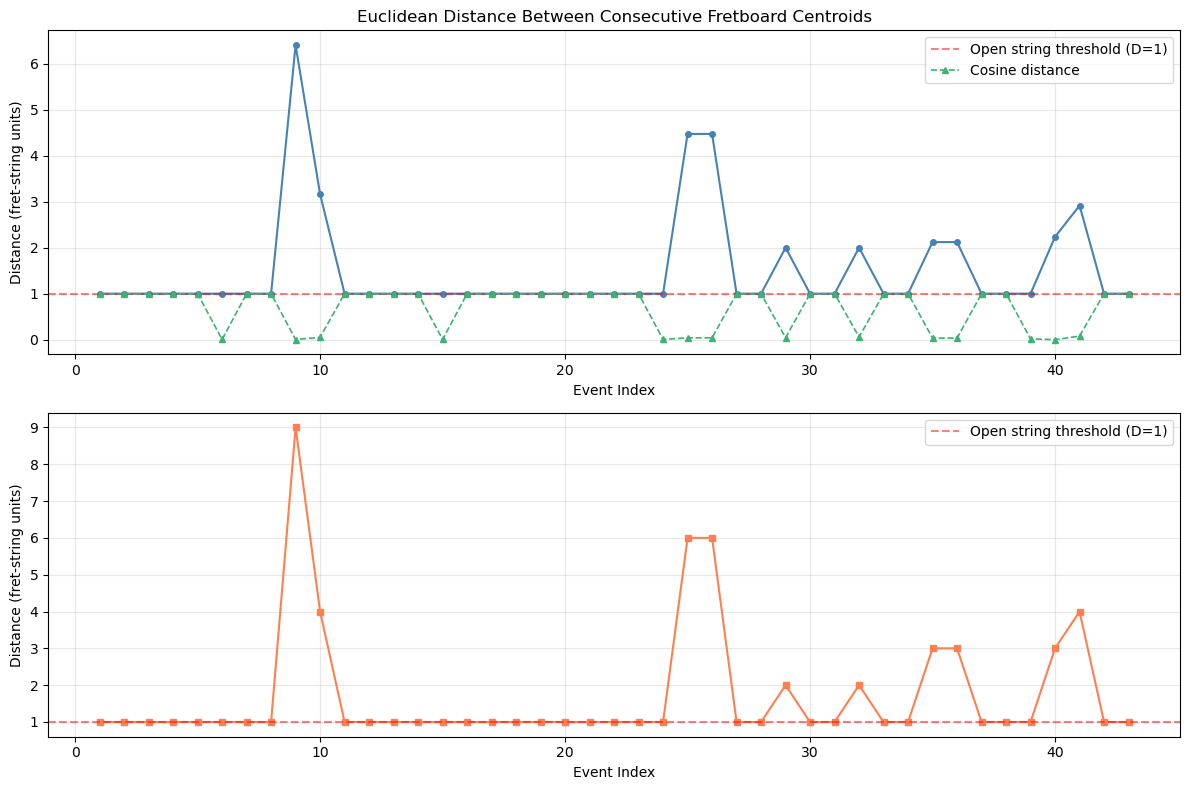

In [ ]:
import matplotlib.pyplot as plt

# Extract time points and distances for plotting
time_points = [t['event_index'] for t in euclidean_trans]
distances_euclidean = [t['distance'] for t in euclidean_trans]
distances_manhattan = [t['distance'] for t in manhattan_trans]
distances_cosine = [t['distance'] for t in cosine_trans]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot Euclidean distances
ax1.plot(time_points, distances_euclidean, marker='o', linestyle='-', linewidth=1.5, markersize=4, color='steelblue')
ax1.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Open string threshold (D=1)')
ax1.set_xlabel('Event Index')
ax1.set_ylabel('Distance (fret-string units)')
ax1.set_title('Euclidean Distance Between Consecutive Fretboard Centroids')
ax1.grid(True, alpha=0.3)
ax1.plot(time_points, distances_cosine, marker='^', linestyle='--', linewidth=1.2, markersize=4, color='mediumseagreen', label='Cosine distance')
ax1.legend()

# Plot Manhattan distances
ax2.plot(time_points, distances_manhattan, marker='s', linestyle='-', linewidth=1.5, markersize=4, color='coral')
ax2.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Open string threshold (D=1)')
ax2.set_xlabel('Event Index')
ax2.set_ylabel('Distance (fret-string units)')
ax2.grid(True, alpha=0.3)
ax2.plot([], [], ' ', label='')
ax2.legend()

plt.tight_layout()
plt.show()
                

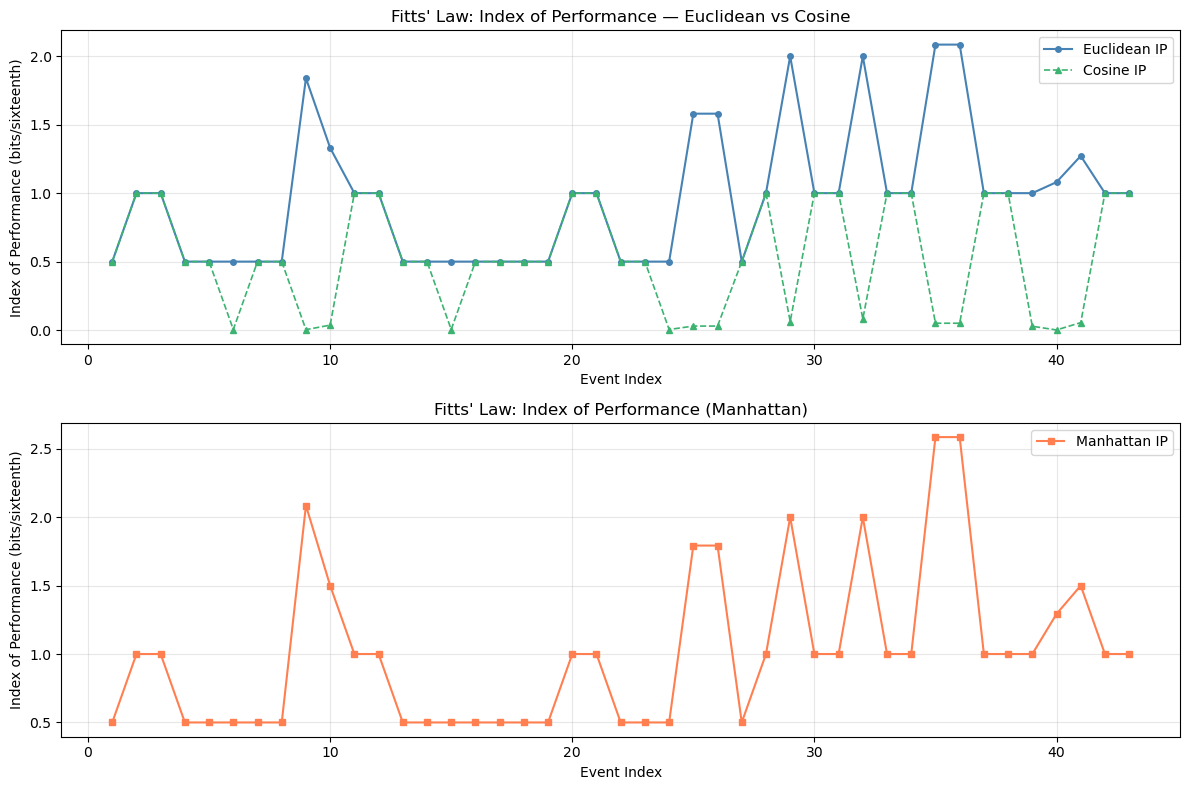

Index of Performance Statistics (Euclidean):
  Min: 0.5000, Max: 2.0850, Mean: 0.9617

Index of Performance Statistics (Manhattan):
  Min: 0.5000, Max: 2.5850, Mean: 1.0147

Index of Performance Statistics (Cosine):
  Min: 0.0008, Max: 1.0000, Mean: 0.5218


In [ ]:
# Plot Fitts' Law metrics: Index of Performance (ID/MT)

# Extract time points and calculate Index of Performance for each transition
time_points = [t['event_index'] for t in euclidean_trans]
ip_euclidean = [t['index_of_difficulty'] / t['duration_sixteenths'] 
                for t in euclidean_trans]
ip_manhattan = [t['index_of_difficulty'] / t['duration_sixteenths'] 
                for t in manhattan_trans]
ip_cosine = [t['index_of_difficulty'] / t['duration_sixteenths'] 
                for t in cosine_trans]

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot Euclidean and Cosine Index of Performance on the same axes for direct comparison
ax1.plot(time_points, ip_euclidean, marker='o', linestyle='-', linewidth=1.5, markersize=4, color='steelblue', label='Euclidean IP')
ax1.plot(time_points, ip_cosine, marker='^', linestyle='--', linewidth=1.2, markersize=4, color='mediumseagreen', label='Cosine IP')
ax1.set_xlabel('Event Index')
ax1.set_ylabel('Index of Performance (bits/sixteenth)')
ax1.set_title("Fitts' Law: Index of Performance — Euclidean vs Cosine")
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

# Plot Manhattan Index of Performance on second axes
ax2.plot(time_points, ip_manhattan, marker='s', linestyle='-', linewidth=1.5, markersize=4, color='coral', label='Manhattan IP')
ax2.set_xlabel('Event Index')
ax2.set_ylabel('Index of Performance (bits/sixteenth)')
ax2.set_title("Fitts' Law: Index of Performance (Manhattan)")
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"Index of Performance Statistics (Euclidean):")
print(f"  Min: {min(ip_euclidean):.4f}, Max: {max(ip_euclidean):.4f}, Mean: {sum(ip_euclidean)/len(ip_euclidean):.4f}")
print(f"\nIndex of Performance Statistics (Manhattan):")
print(f"  Min: {min(ip_manhattan):.4f}, Max: {max(ip_manhattan):.4f}, Mean: {sum(ip_manhattan)/len(ip_manhattan):.4f}")
print(f"\nIndex of Performance Statistics (Cosine):")
print(f"  Min: {min(ip_cosine):.4f}, Max: {max(ip_cosine):.4f}, Mean: {sum(ip_cosine)/len(ip_cosine):.4f}")

# Euclidean distances

In [50]:
# Extract Euclidean distances and Fitts' Law metrics
euclidean_distances = [t['distance'] for t in euclidean_trans]
fitts_law_ids = [t['index_of_difficulty'] for t in euclidean_trans]
durations_quarters = [t['duration_quarters'] for t in euclidean_trans]
durations_sixteenths = [t['duration_sixteenths'] for t in euclidean_trans]
gestural_efforts = [t['gestural_effort'] for t in euclidean_trans]

# Create a combined result
results = {
    'euclidean_distances': euclidean_distances,
    'fitts_law_ids': fitts_law_ids,
    'durations_quarters': durations_quarters,
    'durations_sixteenths': durations_sixteenths,
    'gestural_efforts': gestural_efforts,
    'event_indices': [t['event_index'] for t in euclidean_trans]
}

print("Euclidean Distances:", euclidean_distances)
print("\nFitts' Law Index of Difficulty (bits):", fitts_law_ids)
print("\nDurations (quarter notes):", durations_quarters)
print("\nDurations (sixteenth notes):", durations_sixteenths)
print("\nGestural Effort (ID / Duration):", gestural_efforts)

# Return as separate lists for easy access
euclidean_distances, fitts_law_ids, durations_quarters, durations_sixteenths, gestural_efforts

Euclidean Distances: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 6.4031242374328485, 3.1622776601683795, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 4.47213595499958, 4.47213595499958, 1.0, 1.0, 2.0, 1.0, 1.0, 2.0, 1.0, 1.0, 2.1213203435596424, 2.1213203435596424, 1.0, 1.0, 1.0, 2.23606797749979, 2.9154759474226504, 1.0, 1.0]

Fitts' Law Index of Difficulty (bits): [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 3.678776002309042, 2.6609640474436813, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 3.1609640474436813, 3.1609640474436813, 1.0, 1.0, 2.0, 1.0, 1.0, 2.0, 1.0, 1.0, 2.084962500721156, 2.084962500721156, 1.0, 1.0, 1.0, 2.1609640474436813, 2.54373142062517, 1.0, 1.0]

Durations (quarter notes): [0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.25, 0.25, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.5, 0.5, 0.25, 0.25]

Durations (si

([1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  6.4031242374328485,
  3.1622776601683795,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  4.47213595499958,
  4.47213595499958,
  1.0,
  1.0,
  2.0,
  1.0,
  1.0,
  2.0,
  1.0,
  1.0,
  2.1213203435596424,
  2.1213203435596424,
  1.0,
  1.0,
  1.0,
  2.23606797749979,
  2.9154759474226504,
  1.0,
  1.0],
 [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  3.678776002309042,
  2.6609640474436813,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  3.1609640474436813,
  3.1609640474436813,
  1.0,
  1.0,
  2.0,
  1.0,
  1.0,
  2.0,
  1.0,
  1.0,
  2.084962500721156,
  2.084962500721156,
  1.0,
  1.0,
  1.0,
  2.1609640474436813,
  2.54373142062517,
  1.0,
  1.0],
 [0.5,
  0.25,
  0.25,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.25,
  0.25,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.5,
  0.25,
  0.25,
  0.5,
  0.5,


In [49]:
# Extract Cosine distances and Fitts' Law metrics
cosine_distances = [t['distance'] for t in cosine_trans]
fitts_law_ids_cosine = [t['index_of_difficulty'] for t in cosine_trans]
durations_quarters_cosine = [t['duration_quarters'] for t in cosine_trans]
durations_sixteenths_cosine = [t['duration_sixteenths'] for t in cosine_trans]
gestural_efforts_cosine = [t['gestural_effort'] for t in cosine_trans]

# Create a combined result for cosine
results_cosine = {
    'cosine_distances': cosine_distances,
    'fitts_law_ids_cosine': fitts_law_ids_cosine,
    'durations_quarters_cosine': durations_quarters_cosine,
    'durations_sixteenths_cosine': durations_sixteenths_cosine,
    'gestural_efforts_cosine': gestural_efforts_cosine,
    'event_indices': [t['event_index'] for t in cosine_trans]
}

print("Cosine Distances:", cosine_distances)
print("\nFitts' Law Index of Difficulty (bits, cosine):", fitts_law_ids_cosine)
print("\nDurations (quarter notes, cosine):", durations_quarters_cosine)
print("\nDurations (sixteenth notes, cosine):", durations_sixteenths_cosine)
print("\nGestural Effort (ID / Duration, cosine):", gestural_efforts_cosine)

# Return as separate lists for easy access
cosine_distances, fitts_law_ids_cosine, durations_quarters_cosine, durations_sixteenths_cosine, gestural_efforts_cosine

Cosine Distances: [1.0, 1.0, 1.0, 1.0, 1.0, 0.005690846080190881, 1.0, 1.0, 0.004106793532296149, 0.05131670194948623, 1.0, 1.0, 1.0, 1.0, 0.005690846080190881, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.005690846080190881, 0.04120188729161267, 0.04120188729161267, 1.0, 1.0, 0.044220991278049904, 1.0, 1.0, 0.058258088405162556, 1.0, 1.0, 0.03523617876226781, 0.03523617876226781, 1.0, 1.0, 0.019419324309079666, 0.0011318622755625007, 0.07836462486193474, 1.0, 1.0]

Fitts' Law Index of Difficulty (bits, cosine): [1.0, 1.0, 1.0, 1.0, 1.0, 0.008186882307013246, 1.0, 1.0, 0.0059127178005708575, 0.0721973367647947, 1.0, 1.0, 1.0, 1.0, 0.008186882307013246, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.008186882307013246, 0.05824983189863385, 0.05824983189863385, 1.0, 1.0, 0.06242706562605267, 1.0, 1.0, 0.08169151540561044, 1.0, 1.0, 0.049959941694276935, 0.049959941694276935, 1.0, 1.0, 0.027747606620235267, 0.0016320086615382765, 0.10884507561855129, 1.0, 1.0]

Durations (quarter notes, cosine): 

([1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.005690846080190881,
  1.0,
  1.0,
  0.004106793532296149,
  0.05131670194948623,
  1.0,
  1.0,
  1.0,
  1.0,
  0.005690846080190881,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.005690846080190881,
  0.04120188729161267,
  0.04120188729161267,
  1.0,
  1.0,
  0.044220991278049904,
  1.0,
  1.0,
  0.058258088405162556,
  1.0,
  1.0,
  0.03523617876226781,
  0.03523617876226781,
  1.0,
  1.0,
  0.019419324309079666,
  0.0011318622755625007,
  0.07836462486193474,
  1.0,
  1.0],
 [1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.008186882307013246,
  1.0,
  1.0,
  0.0059127178005708575,
  0.0721973367647947,
  1.0,
  1.0,
  1.0,
  1.0,
  0.008186882307013246,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  1.0,
  0.008186882307013246,
  0.05824983189863385,
  0.05824983189863385,
  1.0,
  1.0,
  0.06242706562605267,
  1.0,
  1.0,
  0.08169151540561044,
  1.0,
  1.0,
  0.049959941694276935,
  0.049959941694276935,
  1.0,
  1.0,
  0.0277476066202